## Aims

This is to compare two different runs (across two different periods) for India. It is
to compare what changes there have been in the historical data between the two. These
will cover different time periods.

I think I would like the r2 and RMSE across the whole dataset, comparing each grid location
at each day, and also each grid location at each month.

In [3]:
run_path_2026_03 = "experiments/notebooks/inputs/20260326_diff/pm25-full_rel-2026-03-r0_s-1.0_mb-1.1-r0.nc"
run_path_2025_11 = "experiments/notebooks/inputs/20260326_diff/pm25-full_rel-2025-11-r0_s-1.0_mb-1.0-r0.nc"

shape_district = "experiments/notebooks/inputs/20260326_diff/India_gis_districts755_2023"
shape_state = "experiments/notebooks/inputs/20260326_diff/india_gis_states28+8_2023"

## Load, align, and compare both runs

This section computes:
- Daily-level comparison over all overlapping grid-day points.
- Monthly-level comparison over all overlapping grid-month points.
- Per-month metrics (each month compared across all overlapping grid cells).

In [4]:
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display
from pathlib import Path


def _resolve_existing_path(raw_path: str) -> Path:
    """Resolve a path robustly for notebook execution from varying working directories."""
    p = Path(raw_path)
    candidates: list[Path] = []

    if p.is_absolute():
        candidates.append(p)
    else:
        candidates.append(Path.cwd() / p)
        candidates.append(p)

        # Try joining relative to a detected repo root (folder containing pyproject.toml).
        for parent in [Path.cwd(), *Path.cwd().parents]:
            if (parent / "pyproject.toml").exists():
                candidates.append(parent / p)
                break

    for c in candidates:
        if c.exists():
            return c.resolve()

    raise FileNotFoundError(
        f"Could not resolve existing path from '{raw_path}'. Tried: {[str(x) for x in candidates]}"
    )


def _flatten_valid_pairs(a: xr.DataArray, b: xr.DataArray) -> tuple[np.ndarray, np.ndarray]:
    """Return flattened paired values where both are finite."""
    av = np.asarray(a.values).ravel()
    bv = np.asarray(b.values).ravel()
    mask = np.isfinite(av) & np.isfinite(bv)
    return av[mask], bv[mask]


def _rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def _r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    y_bar = float(np.mean(y_true))
    ss_tot = float(np.sum((y_true - y_bar) ** 2))
    if ss_tot == 0.0:
        return float("nan")
    return 1.0 - ss_res / ss_tot


# Hard-coded dataset structure learned from inspection
TARGET_VAR = "pm25"
TIME_DIM = "time"
X_DIM = "x"
Y_DIM = "y"
X_COORD = "x"
Y_COORD = "y"

path_2026_03 = _resolve_existing_path(run_path_2026_03)
path_2025_11 = _resolve_existing_path(run_path_2025_11)

# Load both runs
with xr.open_dataset(path_2026_03) as ds_2026_03, xr.open_dataset(path_2025_11) as ds_2025_11:
    required_dims = {TIME_DIM, Y_DIM, X_DIM}
    required_vars = {TARGET_VAR}

    if not required_dims.issubset(set(ds_2025_11.dims)):
        raise ValueError(f"2025-11 dataset missing expected dims {required_dims}. Found: {set(ds_2025_11.dims)}")
    if not required_dims.issubset(set(ds_2026_03.dims)):
        raise ValueError(f"2026-03 dataset missing expected dims {required_dims}. Found: {set(ds_2026_03.dims)}")

    if not required_vars.issubset(set(ds_2025_11.data_vars)):
        raise ValueError(f"2025-11 dataset missing expected vars {required_vars}. Found: {set(ds_2025_11.data_vars)}")
    if not required_vars.issubset(set(ds_2026_03.data_vars)):
        raise ValueError(f"2026-03 dataset missing expected vars {required_vars}. Found: {set(ds_2026_03.data_vars)}")

    da_2026 = ds_2026_03[TARGET_VAR]
    da_2025 = ds_2025_11[TARGET_VAR]

    # Align to overlapping coordinates across shared dimensions.
    da_2026, da_2025 = xr.align(da_2026, da_2025, join="inner")

structure_meta = {
    "time_dim": TIME_DIM,
    "x_dim": X_DIM,
    "y_dim": Y_DIM,
    "x_coord": X_COORD,
    "y_coord": Y_COORD,
    "target_var": TARGET_VAR,
}

summary = pd.DataFrame(
    {
        "dataset": ["2025-11", "2026-03"],
        "dims": [dict(da_2025.sizes), dict(da_2026.sizes)],
        "data_vars": [[TARGET_VAR], [TARGET_VAR]],
        "coords": [list(da_2025.coords), list(da_2026.coords)],
    }
)

# Daily-level metric across all overlapping grid-day points
y_true_daily, y_pred_daily = _flatten_valid_pairs(da_2025, da_2026)

if y_true_daily.size == 0:
    raise ValueError("No overlapping finite values found between runs after alignment.")

daily_summary = pd.DataFrame(
    {
        "comparison_level": ["daily_all_points"],
        "n_pairs": [int(y_true_daily.size)],
        "r2": [_r2(y_true_daily, y_pred_daily)],
        "rmse": [_rmse(y_true_daily, y_pred_daily)],
    }
)

print(f"2025-11 file: {path_2025_11}")
print(f"2026-03 file: {path_2026_03}")
print(f"Using hard-coded variable '{TARGET_VAR}'")
print("Using hard-coded structure:", structure_meta)
display(summary)
display(daily_summary)

/home/panda/programming/india_map/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2025-11 file: /home/panda/programming/india_map/experiments/notebooks/inputs/20260326_diff/pm25-full_rel-2025-11-r0_s-1.0_mb-1.0-r0.nc
2026-03 file: /home/panda/programming/india_map/experiments/notebooks/inputs/20260326_diff/pm25-full_rel-2026-03-r0_s-1.0_mb-1.1-r0.nc
Using hard-coded variable 'pm25'
Using hard-coded structure: {'time_dim': 'time', 'x_dim': 'x', 'y_dim': 'y', 'x_coord': 'x', 'y_coord': 'y', 'target_var': 'pm25'}


,dataset,dims,data_vars,coords
0,2025-11,"{'time': 2618, 'y': 328, 'x': 287}",[pm25],"[time, y, x]"
1,2026-03,"{'time': 2618, 'y': 328, 'x': 287}",[pm25],"[time, y, x]"


,comparison_level,n_pairs,r2,rmse
0,daily_all_points,86587732,0.757415,14.853129


In [5]:
# Monthly-level metric across all overlapping grid-month points
shared_time_dim = TIME_DIM

monthly_2025 = da_2025.resample({shared_time_dim: "MS"}).mean()
monthly_2026 = da_2026.resample({shared_time_dim: "MS"}).mean()
monthly_2025, monthly_2026 = xr.align(monthly_2025, monthly_2026, join="inner")

y_true_monthly, y_pred_monthly = _flatten_valid_pairs(monthly_2025, monthly_2026)

monthly_summary = pd.DataFrame(
    {
        "comparison_level": ["monthly_all_points"],
        "n_pairs": [int(y_true_monthly.size)],
        "r2": [_r2(y_true_monthly, y_pred_monthly)],
        "rmse": [_rmse(y_true_monthly, y_pred_monthly)],
    }
)

display(monthly_summary)


# Per-month metrics: each month compared across all overlapping grid cells
per_month_rows: list[dict[str, float | int | str]] = []
for month_ts in monthly_2025[shared_time_dim].values:
    a = monthly_2025.sel({shared_time_dim: month_ts})
    b = monthly_2026.sel({shared_time_dim: month_ts})
    y_true_m, y_pred_m = _flatten_valid_pairs(a, b)

    if y_true_m.size == 0:
        continue

    per_month_rows.append(
        {
            "month": pd.Timestamp(month_ts).strftime("%Y-%m"),
            "n_pairs": int(y_true_m.size),
            "r2": _r2(y_true_m, y_pred_m),
            "rmse": _rmse(y_true_m, y_pred_m),
        }
    )

per_month_metrics = pd.DataFrame(per_month_rows).sort_values("month").reset_index(drop=True)
display(per_month_metrics)


# Optional quick sanity stats of absolute differences on daily aligned values
abs_diff = np.abs(y_pred_daily - y_true_daily)
sanity_stats = pd.DataFrame(
    {
        "abs_diff_mean": [float(np.mean(abs_diff))],
        "abs_diff_median": [float(np.median(abs_diff))],
        "abs_diff_p95": [float(np.percentile(abs_diff, 95))],
    }
)
display(sanity_stats)

,comparison_level,n_pairs,r2,rmse
0,monthly_all_points,2844364,0.821447,11.428042


,month,n_pairs,r2,rmse
0,2018-08,33074,0.703508,10.932590
1,2018-09,33074,0.682729,10.406784
2,2018-10,33074,0.877352,8.459070
3,2018-11,33074,0.936049,9.786325
4,2018-12,33074,0.936889,10.253315
...,...,...,...,...
81,2025-05,33074,0.067281,12.429969
82,2025-06,33074,0.354146,11.224629
83,2025-07,33074,0.327652,11.897592
84,2025-08,33074,0.199034,12.397233


,abs_diff_mean,abs_diff_median,abs_diff_p95
0,9.698689,5.994961,32.970142


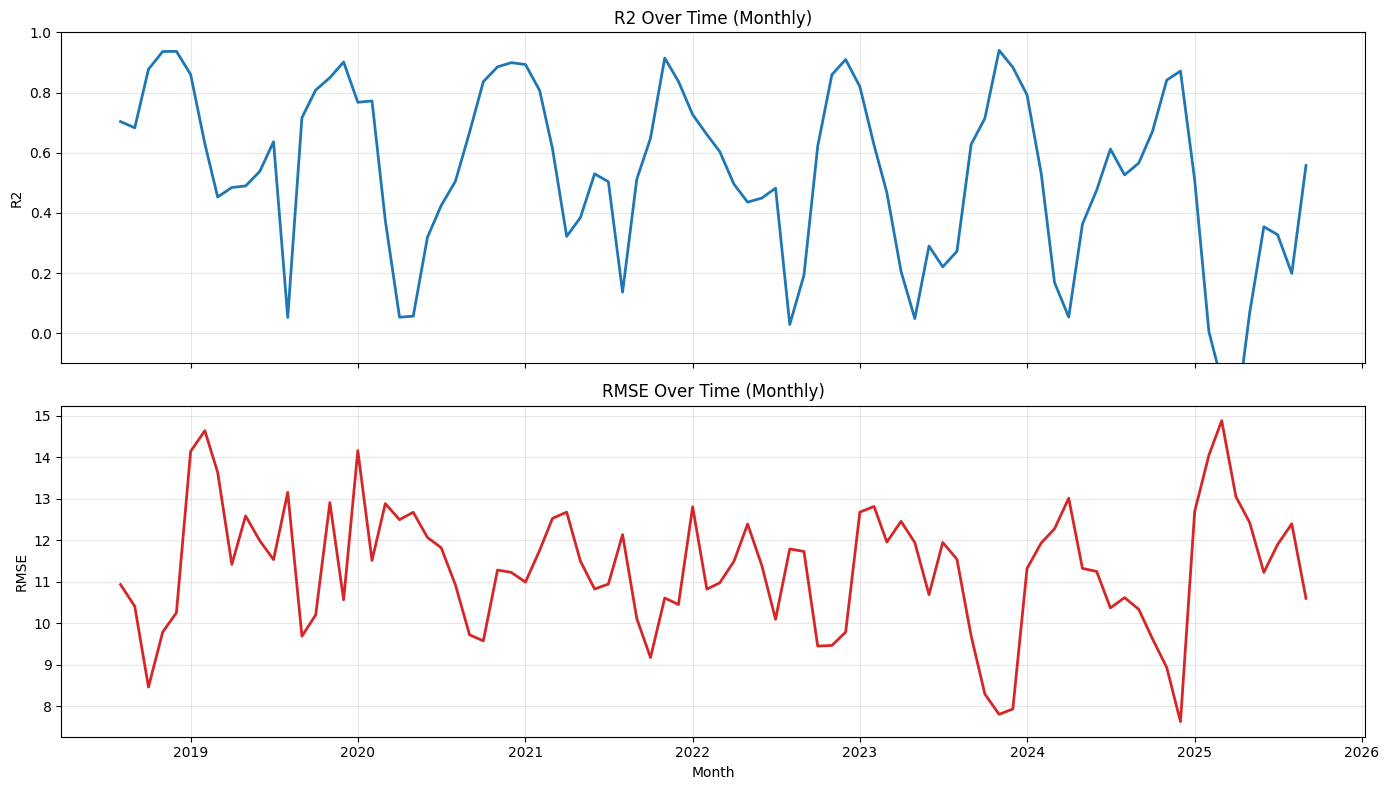

In [9]:
import matplotlib.pyplot as plt

plot_df = per_month_metrics.copy()
plot_df["month"] = pd.to_datetime(plot_df["month"])
plot_df = plot_df.sort_values("month")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(plot_df["month"], plot_df["r2"], color="#1f77b4", linewidth=2)
axes[0].set_title("R2 Over Time (Monthly)")
axes[0].set_ylabel("R2")
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.1, 1.0)

axes[1].plot(plot_df["month"], plot_df["rmse"], color="#d62728", linewidth=2)
axes[1].set_title("RMSE Over Time (Monthly)")
axes[1].set_ylabel("RMSE")
axes[1].set_xlabel("Month")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

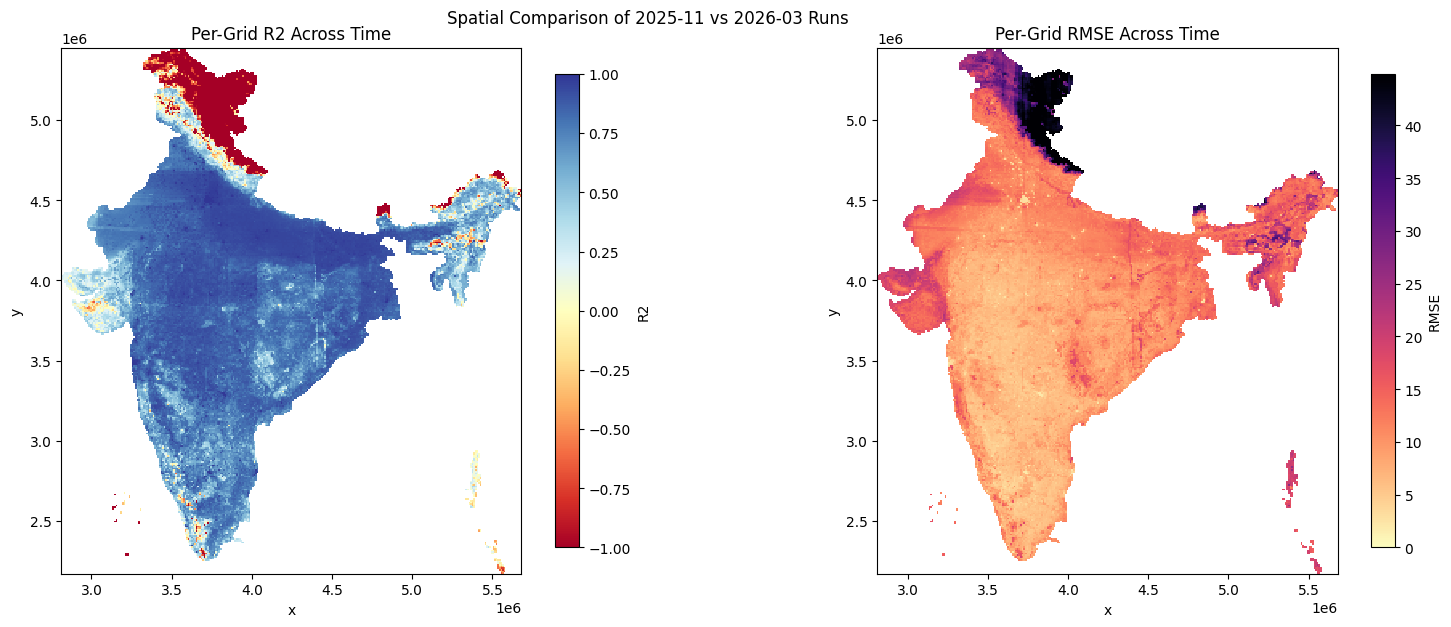

In [13]:
# Spatial maps: per-grid-point R2 and RMSE across time using hard-coded structure

def _plot_spatial_map(
    ax,
    da: xr.DataArray,
    *,
    x_coord: str,
    y_coord: str,
    title: str,
    cmap: str,
    vmin: float | None = None,
    vmax: float | None = None,
):
    """Plot using hard-coded coordinate names."""
    x_values = da[x_coord] if x_coord in da.coords else da.coords[da.dims[-1]]
    y_values = da[y_coord] if y_coord in da.coords else da.coords[da.dims[-2]]

    mesh = ax.pcolormesh(x_values, y_values, da, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xlabel(x_coord)
    ax.set_ylabel(y_coord)
    ax.set_title(title)
    ax.set_aspect("equal")
    return mesh


# Ensure both arrays are still aligned on overlapping coordinates
da_2025_aligned, da_2026_aligned = xr.align(da_2025, da_2026, join="inner")

time_dim = TIME_DIM
x_dim = X_DIM
y_dim = Y_DIM
x_coord = X_COORD
y_coord = Y_COORD

pair_mask = np.isfinite(da_2025_aligned) & np.isfinite(da_2026_aligned)
valid_n = pair_mask.sum(dim=time_dim)

# RMSE per grid point
rmse_grid = np.sqrt(((da_2025_aligned - da_2026_aligned) ** 2).where(pair_mask).mean(dim=time_dim, skipna=True))
rmse_grid = rmse_grid.where(valid_n >= 1)

# R2 per grid point
y_true_mean = da_2025_aligned.where(pair_mask).mean(dim=time_dim, skipna=True)
ss_res = ((da_2025_aligned - da_2026_aligned) ** 2).where(pair_mask).sum(dim=time_dim, skipna=True)
ss_tot = ((da_2025_aligned - y_true_mean) ** 2).where(pair_mask).sum(dim=time_dim, skipna=True)
r2_grid = (1.0 - (ss_res / ss_tot)).where((valid_n >= 2) & (ss_tot > 0))

# Keep maps in (y, x) order for plotting
r2_grid = r2_grid.transpose(y_dim, x_dim)
rmse_grid = rmse_grid.transpose(y_dim, x_dim)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

r2_mesh = _plot_spatial_map(
    axes[0],
    r2_grid,
    x_coord=x_coord,
    y_coord=y_coord,
    title="Per-Grid R2 Across Time",
    cmap="RdYlBu",
    vmin=-1.0,
    vmax=1.0,
)
plt.colorbar(r2_mesh, ax=axes[0], shrink=0.9, label="R2")

rmse_vmax = float(np.nanpercentile(rmse_grid.values, 98))
rmse_mesh = _plot_spatial_map(
    axes[1],
    rmse_grid,
    x_coord=x_coord,
    y_coord=y_coord,
    title="Per-Grid RMSE Across Time",
    cmap="magma_r",
    vmin=0.0,
    vmax=rmse_vmax if np.isfinite(rmse_vmax) else None,
)
plt.colorbar(rmse_mesh, ax=axes[1], shrink=0.9, label="RMSE")

plt.suptitle("Spatial Comparison of 2025-11 vs 2026-03 Runs", y=1.02)
plt.show()

## Spatially-aggregated comparison: state and district level

Both runs are aggregated to monthly means, then each month is spatially
aggregated to state/district level using area-weighted means (via exactextract).
R2 and RMSE are then computed per region across all overlapping months.

In [7]:
import geopandas as gpd
import rioxarray  # noqa: F401 – registers .rio accessor on xarray objects
from exactextract import exact_extract
from pyproj import CRS

# Dataset CRS (EPSG:7755 – WGS 84 / India NSF LCC)
RASTER_CRS = CRS.from_epsg(7755)

# Hard-coded shapefile paths and name columns
# dtname is not unique across states, so we group by dtcode11 (unique) and
# join the human-readable "state – district" label afterwards.
SHAPE_DISTRICT = _resolve_existing_path(
    "experiments/notebooks/inputs/20260326_diff/India_gis_districts755_2023/India_755districts_2023.shp"
)
SHAPE_STATE = _resolve_existing_path(
    "experiments/notebooks/inputs/20260326_diff/india_gis_states28+8_2023/Admin2.shp"
)
DISTRICT_ID_COL = "dtcode11"   # unique numeric code used for grouping
DISTRICT_LABEL_COL = "label"   # "STATE – district" created below
STATE_NAME_COL = "ST_NM"

# Load and reproject to raster CRS
gdf_districts = gpd.read_file(SHAPE_DISTRICT).to_crs(RASTER_CRS)
gdf_districts[DISTRICT_LABEL_COL] = (
    gdf_districts["stname"].str.title() + " – " + gdf_districts["dtname"].str.title()
)
assert gdf_districts[DISTRICT_ID_COL].is_unique, "dtcode11 must be unique"

gdf_states = gpd.read_file(SHAPE_STATE).to_crs(RASTER_CRS)
assert gdf_states[STATE_NAME_COL].is_unique, "State names must be unique"

print(
    f"Loaded {len(gdf_districts)} districts and {len(gdf_states)} states "
    f"(reprojected to EPSG:7755)"
)


def _aggregate_to_regions(
    monthly_da: xr.DataArray,
    gdf: gpd.GeoDataFrame,
    id_col: str,
) -> pd.DataFrame:
    """
    For each month slice in monthly_da, aggregate pixel values to regions
    using exactextract area-weighted mean.

    Returns a DataFrame with columns [id_col, 'month', 'pm25_mean'].
    """
    da = monthly_da.rio.write_crs(RASTER_CRS, inplace=False)
    da = da.rio.set_spatial_dims(x_dim=X_DIM, y_dim=Y_DIM, inplace=False)

    records: list[pd.DataFrame] = []
    for ts in da[TIME_DIM].values:
        da_month = da.sel({TIME_DIM: ts})
        rows = exact_extract(
            da_month,
            gdf,
            ops=["mean(coverage_weight=area_cartesian)"],
            include_cols=[id_col],
            output="pandas",
        ).rename(columns={"mean": "pm25_mean"})
        rows["month"] = pd.Timestamp(ts).strftime("%Y-%m")
        records.append(rows)

    return pd.concat(records, ignore_index=True)


# Aggregate monthly means for both runs to districts and states
print("Aggregating to districts …")
agg_2025_district = _aggregate_to_regions(monthly_2025, gdf_districts, DISTRICT_ID_COL)
agg_2026_district = _aggregate_to_regions(monthly_2026, gdf_districts, DISTRICT_ID_COL)

print("Aggregating to states …")
agg_2025_state = _aggregate_to_regions(monthly_2025, gdf_states, STATE_NAME_COL)
agg_2026_state = _aggregate_to_regions(monthly_2026, gdf_states, STATE_NAME_COL)

print("Done.")

Loaded 755 districts and 36 states (reprojected to EPSG:7755)
Aggregating to districts …
Aggregating to states …
Done.


In [8]:
def _region_metrics(
    agg_a: pd.DataFrame,
    agg_b: pd.DataFrame,
    name_col: str,
    label: str,
) -> pd.DataFrame:
    """
    Join two region-month aggregations on (name_col, month) and compute
    per-region R2 and RMSE across all overlapping months.
    Also prints one single global statistic line (all region-months pooled).
    """
    merged = agg_a.merge(
        agg_b,
        on=[name_col, "month"],
        suffixes=("_2025", "_2026"),
        how="inner",
    ).dropna(subset=["pm25_mean_2025", "pm25_mean_2026"])

    rows: list[dict] = []
    for region, grp in merged.groupby(name_col):
        y_true = grp["pm25_mean_2025"].to_numpy()
        y_pred = grp["pm25_mean_2026"].to_numpy()
        rows.append(
            {
                name_col: region,
                "n_months": len(grp),
                "r2": _r2(y_true, y_pred),
                "rmse": _rmse(y_true, y_pred),
            }
        )

    df = pd.DataFrame(rows).sort_values("r2", ascending=False).reset_index(drop=True)

    print(f"\n{label} — single global statistic (all region-months pooled):")
    global_y_true = merged["pm25_mean_2025"].to_numpy()
    global_y_pred = merged["pm25_mean_2026"].to_numpy()
    display(
        pd.DataFrame(
            {
                "comparison_level": [f"{label}_all_region_months"],
                "n_pairs": [len(merged)],
                "r2": [_r2(global_y_true, global_y_pred)],
                "rmse": [_rmse(global_y_true, global_y_pred)],
            }
        )
    )
    return df


# District metrics – join readable "State – District" label for display
district_metrics = _region_metrics(agg_2025_district, agg_2026_district, DISTRICT_ID_COL, "Districts")
label_map = gdf_districts.set_index(DISTRICT_ID_COL)[DISTRICT_LABEL_COL]
district_metrics[DISTRICT_LABEL_COL] = district_metrics[DISTRICT_ID_COL].map(label_map)
district_metrics = district_metrics[[DISTRICT_LABEL_COL, DISTRICT_ID_COL, "n_months", "r2", "rmse"]]

print("\nPer-district R2 and RMSE (sorted by R2 descending):")
display(district_metrics)

# State metrics
state_metrics = _region_metrics(agg_2025_state, agg_2026_state, STATE_NAME_COL, "States")
print("\nPer-state R2 and RMSE (sorted by R2 descending):")
display(state_metrics)


Districts — single global statistic (all region-months pooled):


,comparison_level,n_pairs,r2,rmse
0,Districts_all_region_months,64930,0.964741,5.626002



Per-district R2 and RMSE (sorted by R2 descending):


,label,dtcode11,n_months,r2,rmse
0,Delhi – Central,095,86,0.999975,0.300185
1,Delhi – New Delhi,094,86,0.999975,0.300442
2,Delhi – South East,703,86,0.999966,0.380437
3,Delhi – East,093,86,0.999963,0.366041
4,Delhi – North,091,86,0.999956,0.448992
...,...,...,...,...,...
750,Ladakh – Kargil,004,86,-4.799379,31.960592
751,Himachal Pradesh – Kinnaur,034,86,-5.108358,36.947400
752,Ladakh – Leh,003,86,-5.404671,32.660948
753,Sikkim – North District,241,86,-6.672698,21.471899



States — single global statistic (all region-months pooled):


,comparison_level,n_pairs,r2,rmse
0,States_all_region_months,3096,0.910287,7.937058



Per-state R2 and RMSE (sorted by R2 descending):


,ST_NM,n_months,r2,rmse
0,Delhi,86,0.999971,0.316731
1,Bihar,86,0.998478,1.827225
2,Chandigarh,86,0.998207,1.091193
3,Uttar Pradesh,86,0.996617,2.222665
4,Haryana,86,0.995746,2.100914
5,West Bengal,86,0.995403,2.262959
6,Jharkhand,86,0.993446,1.974979
7,Andhra Pradesh,86,0.992612,1.017622
8,Madhya Pradesh,86,0.992601,1.603343
9,Odisha,86,0.992544,1.740553


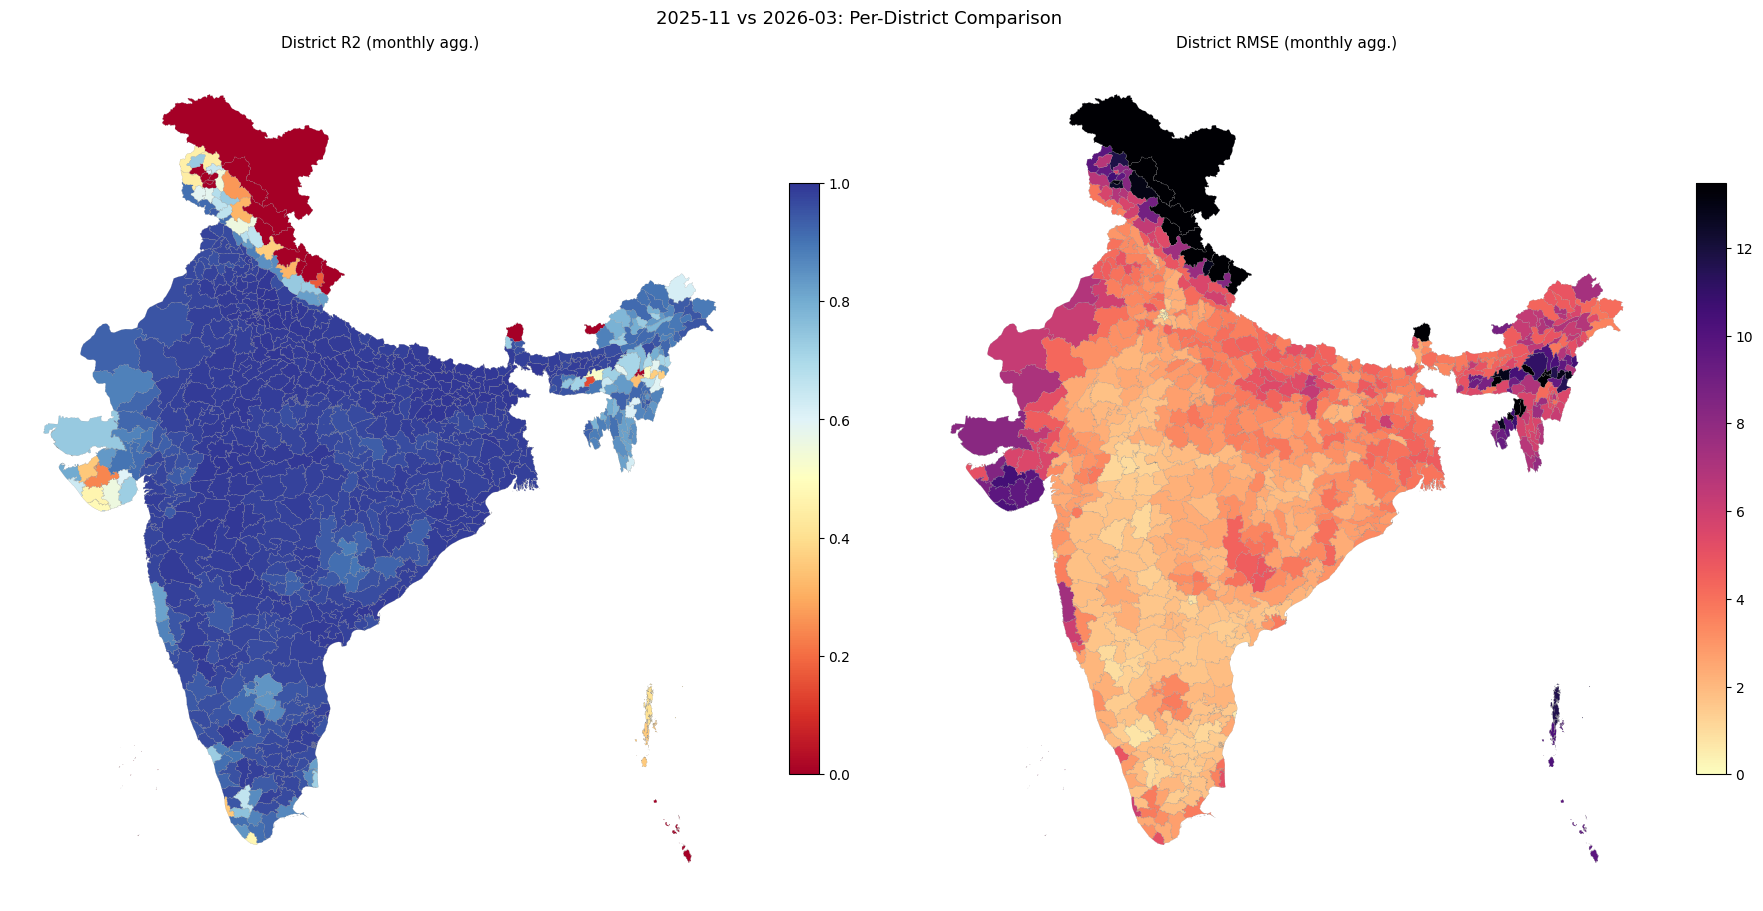

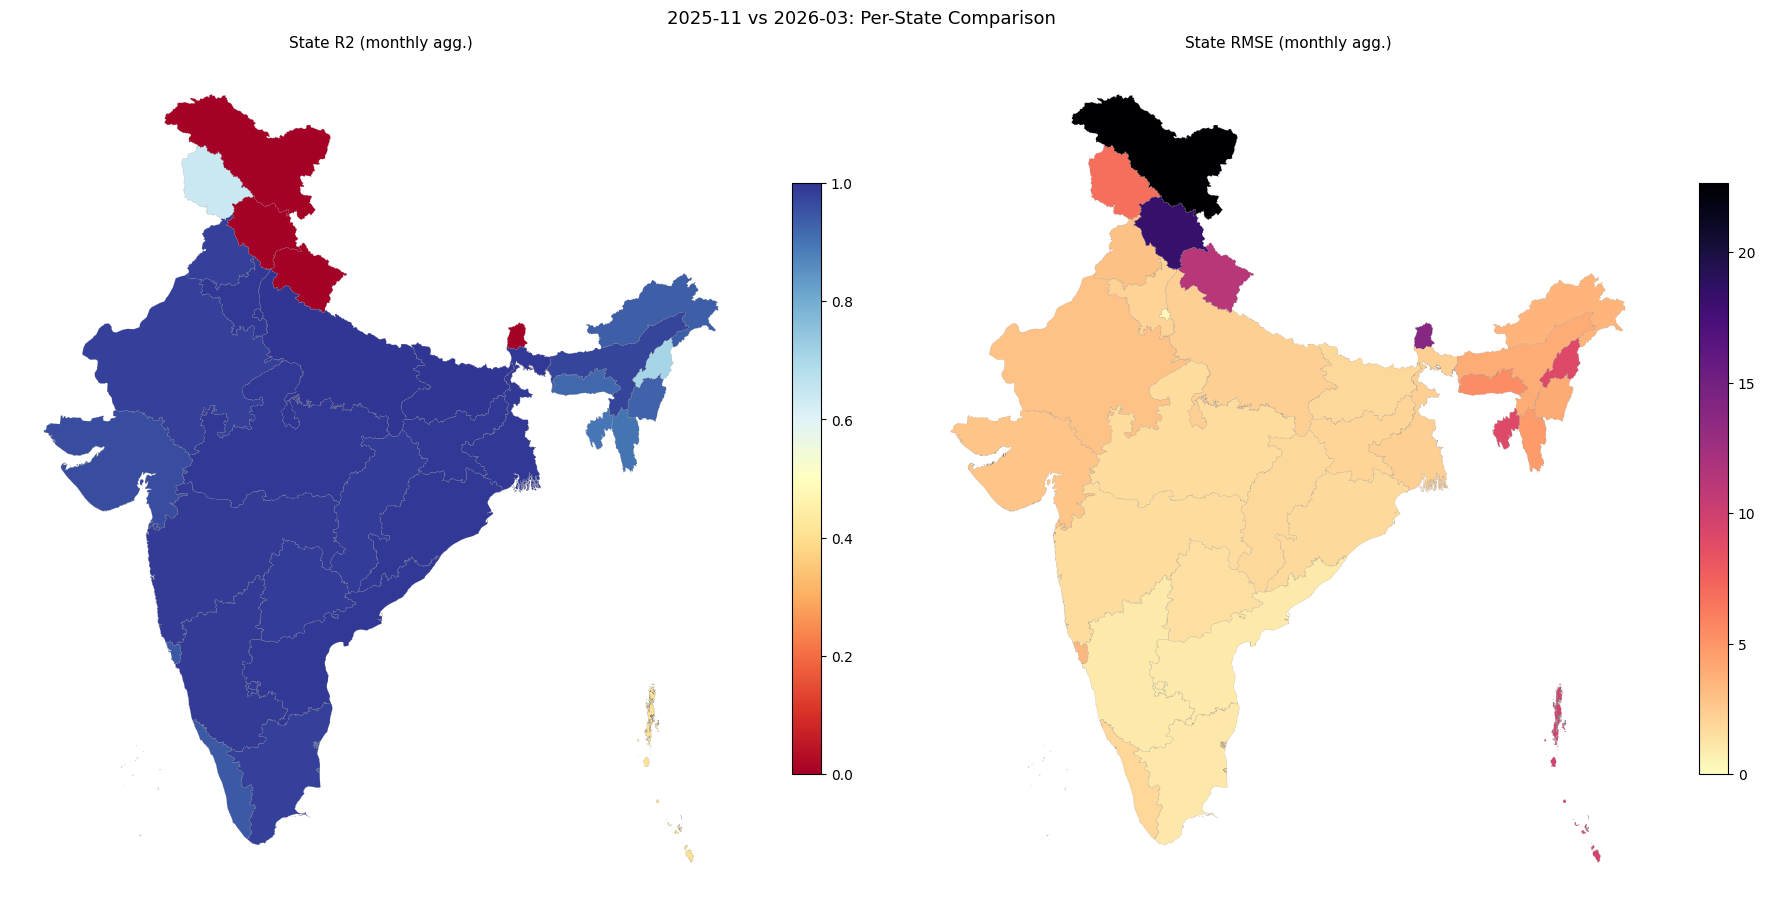

In [10]:

import matplotlib.pyplot as plt
import numpy as np

# Choropleth maps: per-district and per-state R2 and RMSE

def _plot_choropleth(
    gdf: gpd.GeoDataFrame,
    col: str,
    ax,
    title: str,
    cmap: str,
    vmin: float,
    vmax: float,
):
    gdf.plot(column=col, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, linewidth=0.1, edgecolor="grey")
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.7)


# ── District-level ──────────────────────────────────────────────────────────
gdf_d = gdf_districts.merge(
    district_metrics[[DISTRICT_ID_COL, "r2", "rmse"]],
    on=DISTRICT_ID_COL,
    how="left",
)

fig, axes = plt.subplots(1, 2, figsize=(18, 9), constrained_layout=True)
rmse_vmax_d = float(np.nanpercentile(gdf_d["rmse"].dropna(), 98))

_plot_choropleth(gdf_d, "r2",   axes[0], "District R2 (monthly agg.)",   "RdYlBu",  vmin=0.0, vmax=1.0)
_plot_choropleth(gdf_d, "rmse", axes[1], "District RMSE (monthly agg.)", "magma_r", vmin=0.0, vmax=rmse_vmax_d)
fig.suptitle("2025-11 vs 2026-03: Per-District Comparison", fontsize=13)
plt.show()

# ── State-level ──────────────────────────────────────────────────────────────
gdf_s = gdf_states.merge(
    state_metrics[[STATE_NAME_COL, "r2", "rmse"]],
    on=STATE_NAME_COL,
    how="left",
)

fig, axes = plt.subplots(1, 2, figsize=(18, 9), constrained_layout=True)
rmse_vmax_s = float(np.nanpercentile(gdf_s["rmse"].dropna(), 98))

_plot_choropleth(gdf_s, "r2",   axes[0], "State R2 (monthly agg.)",   "RdYlBu",  vmin=0.0, vmax=1.0)
_plot_choropleth(gdf_s, "rmse", axes[1], "State RMSE (monthly agg.)", "magma_r", vmin=0.0, vmax=rmse_vmax_s)
fig.suptitle("2025-11 vs 2026-03: Per-State Comparison", fontsize=13)
plt.show()
